# Spoken Grammar Scoring — GSF final experiment

This notebook evaluates the remaining higher-value experiments on the current dataset: layer-wise WavLM pooling, tuned Ridge and SVR, MAE-aware selection, transcript timing features, and nested comparison of a single model with mean, median, and calibrated blends.

All model choices, blend weights, and calibration are selected using training folds. RMSE and MAE are both reported; `PRIMARY_METRIC` should match the competition Evaluation page. Outputs are isolated in `outputs/gsf/`.

## Pipeline overview

1. Validate train/test audio IDs and inspect score balance.
2. Reuse audio-QC, prosody, transcript, and fold caches where valid.
3. Extract WavLM mean/std pooled embeddings for every hidden layer and add word timing statistics.
4. Compare tuned Ridge/SVR across WavLM layers and robust LightGBM objectives on combined features.
5. Use nested CV to select the candidate, blend, and calibration without scoring on the test labels.
6. Save the chosen test predictions, alternate blend predictions, CV diagnostics, and final model under `outputs/gsf/`.

This is a compact-data experiment, not a promise of a particular leaderboard gain. The WavLM layer extraction is the slowest new step and caches resumably.

## 0. Environment check

Show the Python, PyTorch, and CUDA versions and check whether the libraries needed by the notebook are importable. Resolve any missing package before running the modeling section.


In [1]:
import sys
import importlib.util
import hashlib
import json
import random
import re
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import joblib
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf
import torch
from IPython.display import Audio, display
from scipy.stats import pearsonr, spearmanr
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm


try:
    from transformers import AutoFeatureExtractor, AutoModel
except ImportError:
    AutoFeatureExtractor = AutoModel = None

try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    SentenceTransformer = None

try:
    from faster_whisper import WhisperModel
except ImportError:
    WhisperModel = None

try:
    import spacy
except ImportError:
    spacy = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name} ({gpu.total_memory / 1e9:.1f} GB)")

for package in ("faster_whisper", "transformers", "safetensors", "sentence_transformers", "spacy", "lightgbm", "librosa", "soundfile", "sklearn"):
    installed = importlib.util.find_spec(package) is not None
    print(f"{'OK' if installed else 'MISSING'}: {package}")


d:\grammar_scoring\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python 3.10.7 | PyTorch 2.5.1+cu121 | CUDA: True
GPU: NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB)
OK: faster_whisper
OK: transformers
OK: safetensors
OK: sentence_transformers
OK: spacy
OK: lightgbm
OK: librosa
OK: soundfile
OK: sklearn


## 1. Configuration and helpers

Set the random seed and cross-validation configuration, resolve the project folders, and define metric and fold helpers. These shared settings keep the exploratory baseline and final model evaluation aligned.


In [2]:
@dataclass(frozen=True)
class CFG:
    """Shared settings for reproducible experiments."""
    seed: int = 42
    sr: int = 16_000
    n_splits: int = 5
    n_repeats: int = 3
    score_min: float = 0.0
    score_max: float = 5.0


PRIMARY_METRIC = "mae"  # Change to "rmse" only if the competition metric says RMSE.
RIDGE_ALPHAS = (0.1, 1.0, 10.0, 30.0, 100.0, 300.0, 1000.0)
ENABLE_WORD_TIMESTAMPS = True
ENABLE_MINILM = False  # MiniLM was weak alone; omit its cost in this final run.


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(CFG.seed)

ROOT = Path.cwd()
RAW = ROOT / "data" / "raw"
CACHE = ROOT / "cache"
OUT = ROOT / "outputs" / "gsf"

assert RAW.exists(), f"Expected data at {RAW}. Start Jupyter from the project root."
CACHE.mkdir(exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
assert PRIMARY_METRIC in {"mae", "rmse"}
print(f"Project root: {ROOT} | selection metric: {PRIMARY_METRIC.upper()}")

Project root: d:\grammar_scoring | selection metric: MAE


### 1.1 Metrics and fold utilities

`rmse` and `evaluate` score predictions. `log_result` records baseline results. `make_strat_bins` and `build_folds` create repeatable stratified splits.


In [3]:
def rmse(y, prediction) -> float:
    y = np.asarray(y, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    return float(np.sqrt(np.mean((y - prediction) ** 2)))


def evaluate(y, prediction) -> dict:
    """Return RMSE, MAE, Pearson, and Spearman metrics."""
    y = np.asarray(y, dtype=float)
    prediction = np.asarray(prediction, dtype=float)
    constant = np.std(prediction) < 1e-12
    return {
        "rmse": rmse(y, prediction),
        "mae": float(np.mean(np.abs(y - prediction))),
        "pearson": np.nan if constant else float(pearsonr(y, prediction).statistic),
        "spearman": np.nan if constant else float(spearmanr(y, prediction).statistic),
    }


RESULTS = []


def log_result(name, y, oof_predictions) -> pd.DataFrame:
    """Add one model's repeated out-of-fold metrics to the results table."""
    scores = pd.DataFrame(
        [evaluate(y, predictions) for predictions in oof_predictions]
    )
    row = {
        "model": name,
        "cv_rmse": scores.rmse.mean(),
        "cv_rmse_std": scores.rmse.std(ddof=0),
        "cv_pearson": scores.pearson.mean(),
        "cv_spearman": scores.spearman.mean(),
        "cv_mae": scores.mae.mean(),
    }
    RESULTS[:] = [result for result in RESULTS if result["model"] != name]
    RESULTS.append(row)
    return pd.DataFrame(RESULTS).round(4)


def make_strat_bins(y, min_count):
    """Merge rare neighboring score values until each bin is large enough."""
    values = np.sort(np.unique(y))
    groups = [[value] for value in values]
    counts = [int((y == value).sum()) for value in values]

    while len(groups) > 1 and min(counts) < min_count:
        index = int(np.argmin(counts))
        if index == 0:
            neighbor = 1
        elif index == len(groups) - 1:
            neighbor = index - 1
        else:
            neighbor = index - 1 if counts[index - 1] <= counts[index + 1] else index + 1
        left, right = sorted((index, neighbor))
        groups[left].extend(groups[right])
        counts[left] += counts[right]
        del groups[right]
        del counts[right]

    bins = np.zeros(len(y), dtype=int)
    for bin_id, group in enumerate(groups):
        bins[np.isin(y, group)] = bin_id
    return bins


def build_folds(y, cfg):
    """Create repeat-by-row fold assignments and their stratification bins."""
    bins = make_strat_bins(y, min_count=cfg.n_splits * 2)
    folds = np.zeros((cfg.n_repeats, len(y)), dtype=int)
    for repeat in range(cfg.n_repeats):
        splitter = StratifiedKFold(
            n_splits=cfg.n_splits,
            shuffle=True,
            random_state=cfg.seed + repeat,
        )
        for fold, (_, validation_indices) in enumerate(
            splitter.split(np.zeros(len(y)), bins)
        ):
            folds[repeat, validation_indices] = fold
    return folds, bins

## 2. Load data and validate IDs

Read training labels, test IDs, and the sample output schema. Resolve audio paths and report missing files, duplicate IDs, and ID overlap for inspection.

`test.csv` defines which recordings to predict. The sample file is used only as a column-format reference.

In [4]:
# Resolve files within their split: train and test may reuse the same basename.
train = pd.read_csv(RAW / "train.csv")
test = pd.read_csv(RAW / "test.csv").drop(columns="label", errors="ignore")  # test labels are random placeholders
sample_sub = pd.read_csv(RAW / "sample_submission.csv")

for split, df in (("train", train), ("test", test)):
    audio_dir = RAW / split
    assert audio_dir.is_dir(), f"Expected audio folder: {audio_dir}"
    df["path"] = df["filename"].map(lambda name: audio_dir / name)
    df["path_exists"] = df["path"].map(Path.is_file)


def names(df):
    return set(df["filename"])


train_missing = train.loc[~train.path_exists, "filename"].tolist()
test_missing = test.loc[~test.path_exists, "filename"].tolist()
train_disk = {p.name for p in (RAW / "train").glob("*.wav")}
test_disk = {p.name for p in (RAW / "test").glob("*.wav")}
print(f"train {len(train)} | test {len(test)} | sample_submission {len(sample_sub)}")
print("train files missing on disk:", len(train_missing), "| test files missing on disk:", len(test_missing))
print("duplicate filenames in train:", int(train.filename.duplicated().sum()), "| in test:", int(test.filename.duplicated().sum()))
print("train ? test:", len(names(train) & names(test)))
only_test = sorted(names(test) - names(sample_sub))
only_sub = sorted(names(sample_sub) - names(test))
print(f"in test.csv but NOT in sample_submission: {len(only_test)}  e.g. {only_test[:5]}")
print(f"in sample_submission but NOT in test.csv: {len(only_sub)}  e.g. {only_sub[:5]}")
print("unreferenced WAVs on disk (train/test):", len(train_disk - names(train)), "/", len(test_disk - names(test)))
print("sample_submission columns:", list(sample_sub.columns), "| label values:", sample_sub["label"].unique()[:3])

assert not train_missing, f"Training audio files missing from data/raw/train: {train_missing[:10]}"
assert not test_missing, f"Test audio files missing from data/raw/test: {test_missing[:10]}"
train = train.drop(columns="path_exists")
test = test.drop(columns="path_exists")


train 769 | test 216 | sample_submission 204
train files missing on disk: 0 | test files missing on disk: 0
duplicate filenames in train: 0 | in test: 0
train ? test: 212
in test.csv but NOT in sample_submission: 191  e.g. ['audio_0.wav', 'audio_1.wav', 'audio_10.wav', 'audio_100.wav', 'audio_101.wav']
in sample_submission but NOT in test.csv: 179  e.g. ['audio_1001.wav', 'audio_1006.wav', 'audio_1011.wav', 'audio_1025.wav', 'audio_1028.wav']
unreferenced WAVs on disk (train/test): 0 / 0
sample_submission columns: ['filename', 'label'] | label values: [-1]


## 3. Target distribution and baseline

Review the score range and class counts. The mean-label prediction is the reference point: a useful model should achieve a lower cross-validation RMSE.


count    769.000
mean       3.313
std        1.239
min        0.000
25%        2.500
50%        3.000
75%        4.000
max        5.000
Name: label, dtype: float64


label,0.0,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0
clips,37,1,3,102,79,174,64,124,52,133


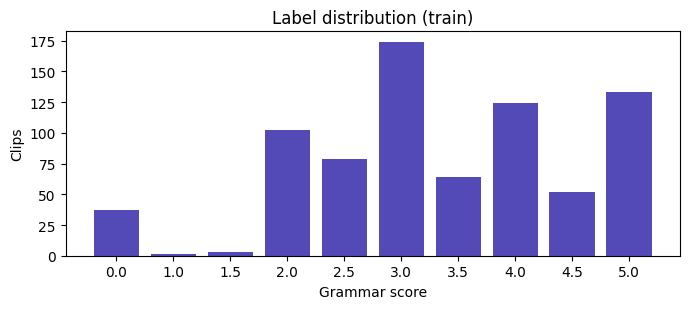

Always predicting the mean gives RMSE = label std = 1.2382. Every model has to beat this.


In [5]:
y = train["label"].to_numpy(float)
print(train["label"].describe().round(3))
counts = train["label"].value_counts().sort_index()
display(counts.to_frame("clips").T)

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(counts.index.astype(str), counts.values, color="#534AB7")
ax.set(xlabel="Grammar score", ylabel="Clips", title="Label distribution (train)")
plt.tight_layout(); plt.savefig(OUT / "label_distribution.png", dpi=150); plt.show()

print(f"Always predicting the mean gives RMSE = label std = {y.std():.4f}. Every model has to beat this.")

## 4. Audio quality checks

Measure duration, sample rate, channel count, peak level, RMS loudness, clipping, and file hashes. Results are cached in `cache/audio_meta.csv` so unchanged files do not need to be scanned again.


### 4.1 Audio metadata cache

`audio_qc` measures recording properties. The cell reuses `cache/audio_meta.csv` when its rows match the current audio files.


In [6]:
QC_CSV = CACHE / "audio_meta.csv"


def audio_qc(path) -> dict:
    """Cheap per-file checks; the raw audio is not modified."""
    info = sf.info(str(path))
    x, _ = sf.read(str(path), dtype="float32", always_2d=True)
    rms = float(np.sqrt(np.mean(x.mean(axis=1) ** 2)) + 1e-12)
    return {"duration": info.duration, "sr": info.samplerate, "channels": info.channels,
            "peak": float(np.abs(x).max()), "rms_db": 20 * np.log10(rms),
            "clip_frac": float((np.abs(x) >= 0.999).mean()),
            "md5": hashlib.md5(Path(path).read_bytes()).hexdigest()}


all_files = pd.concat([train.assign(split="train"), test.assign(split="test")], ignore_index=True)
qc_keys = all_files[["split", "filename", "path"]].copy()
required_qc_columns = {"split", "filename", "duration", "sr", "channels", "peak", "rms_db", "clip_frac", "md5"}
if QC_CSV.exists():
    qc = pd.read_csv(QC_CSV)
    cache_ok = (
        required_qc_columns.issubset(qc.columns)
        and not qc.duplicated(["split", "filename"]).any()
        and set(map(tuple, qc[["split", "filename"]].to_numpy()))
            == set(map(tuple, qc_keys[["split", "filename"]].to_numpy()))
    )
else:
    cache_ok = False

# Old caches keyed only by filename cannot distinguish train/test; rebuild them.
if not cache_ok:
    rows = [{"split": split, "filename": filename, **audio_qc(path)}
            for split, filename, path in tqdm(qc_keys.itertuples(index=False, name=None), total=len(qc_keys))]
    qc = pd.DataFrame(rows)
    qc.to_csv(QC_CSV, index=False)

meta = all_files[["filename", "split", "label"]].merge(
    qc, on=["split", "filename"], validate="one_to_one")


## 5. Listen to example recordings

Compare one recording at each end of the training score range. This is a qualitative spot check to help connect the labels with the audio; it is not part of model training.


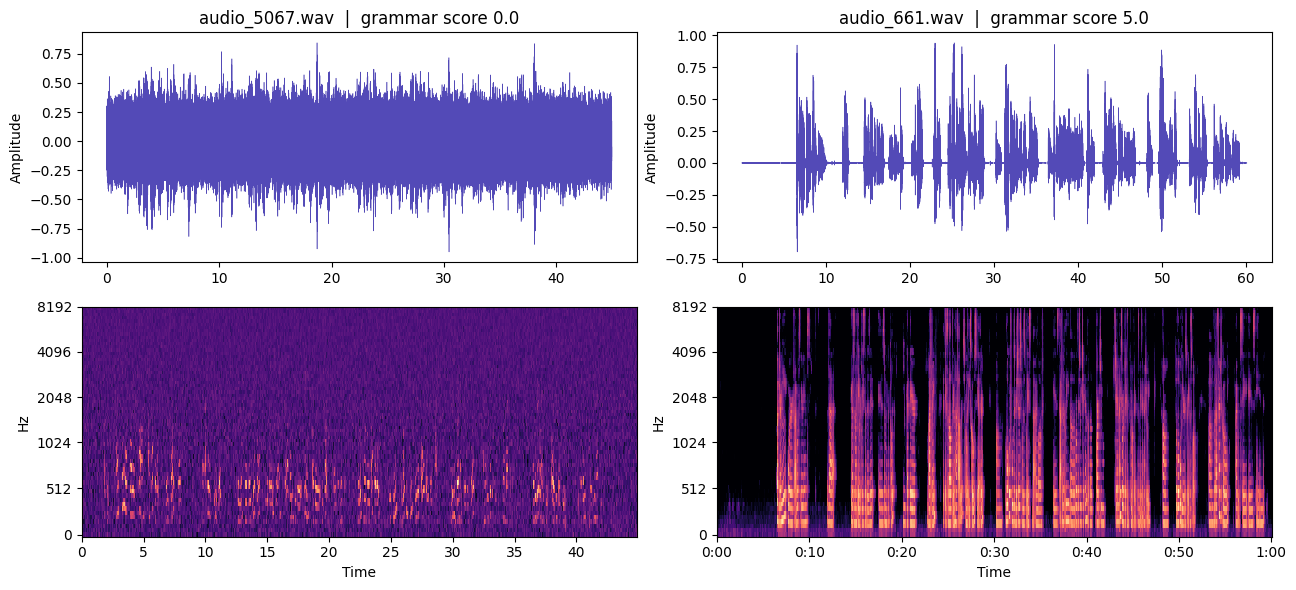

audio_5067.wav  (score 0.0)


audio_661.wav  (score 5.0)


In [7]:
lo = train[train.label == train.label.min()].sample(1, random_state=CFG.seed).iloc[0]
hi = train[train.label == train.label.max()].sample(1, random_state=CFG.seed).iloc[0]

fig, axes = plt.subplots(2, 2, figsize=(13, 6))
for col, row in enumerate([lo, hi]):
    wav, sr = librosa.load(str(row.path), sr=CFG.sr, mono=True)
    axes[0, col].plot(np.arange(len(wav)) / sr, wav, lw=0.4, color="#534AB7")
    axes[0, col].set(title=f"{row.filename}  |  grammar score {row.label}", ylabel="Amplitude")
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=wav, sr=sr, n_mels=64), ref=np.max)
    librosa.display.specshow(mel, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, col])
plt.tight_layout(); plt.savefig(OUT / "example_low_vs_high.png", dpi=150); plt.show()

for row in (lo, hi):  # listen to them: it builds intuition for what the raters heard
    print(f"{row.filename}  (score {row.label})")
    wav, sr = librosa.load(str(row.path), sr=CFG.sr, mono=True)
    display(Audio(wav, rate=sr))

## 6. Repeated cross-validation folds

Build five stratified folds for each of three shuffled repeats. Rare score values are grouped into neighboring bins before stratification. The assignments are saved in `cache/folds.csv` so model comparisons use the same splits.

Each recording is from a different speaker, so there is no repeated-speaker grouping to apply. Stratification by score is appropriate for these folds. If the training row order or labels change, rebuild the fold cache before comparing results.


### 6.1 Reusable stratified splits

Load the cached fold assignments or rebuild them when filenames or labels change. `folds_iter` yields train and validation indices for one repeat.


In [8]:
FOLDS_CSV = CACHE / "folds.csv"
fold_columns = [f"fold_r{repeat}" for repeat in range(CFG.n_repeats)]

fold_cache_valid = False
if FOLDS_CSV.exists():
    cached_folds = pd.read_csv(FOLDS_CSV)
    fold_cache_valid = (
        {"filename", "label", *fold_columns}.issubset(cached_folds.columns)
        and cached_folds.filename.tolist() == train.filename.tolist()
        and np.allclose(cached_folds.label.to_numpy(float), y)
    )

if fold_cache_valid:
    folds = cached_folds[fold_columns].to_numpy().T
else:
    folds, bins = build_folds(y, CFG)
    fold_data = {
        "filename": train.filename,
        "label": y,
        "bin": bins,
        **{column: folds[repeat] for repeat, column in enumerate(fold_columns)},
    }
    pd.DataFrame(fold_data).to_csv(FOLDS_CSV, index=False)


def folds_iter(repeat):
    """Yield training and validation row indices for one repeat."""
    for fold in range(CFG.n_splits):
        validation = np.flatnonzero(folds[repeat] == fold)
        training = np.flatnonzero(folds[repeat] != fold)
        yield training, validation


display(
    pd.DataFrame({"fold": folds[0], "label": y})
    .groupby("fold").label.agg(["size", "mean"]).round(3).T
)

fold,0,1,2,3,4
size,154.000,154.000,154.000,154.000,153.000
mean,3.325,3.282,3.318,3.318,3.324


## 7. Mean prediction baseline

Generate out-of-fold predictions that use only the mean score of each training fold. This establishes a leakage-free RMSE reference for the feature-based models.


In [9]:
oof_mean = np.zeros((CFG.n_repeats, len(y)))
for repeat in range(CFG.n_repeats):
    for train_indices, validation_indices in folds_iter(repeat):
        oof_mean[repeat, validation_indices] = y[train_indices].mean()

log_result("Mean baseline", y, oof_mean)

,model,cv_rmse,cv_rmse_std,cv_pearson,cv_spearman,cv_mae
0,Mean baseline,1.2382,0.0,-0.0111,-0.0061,0.9964


## 8. Model training and predictions

The following cells prepare features, compare models on the fixed repeated folds, select the lowest-RMSE configuration, and refit it on all labeled examples.


### 8.1 Run requirements

Run setup, data checks, and fold cells first. Whisper `small.en` is used for transcript and word-timing features. WavLM-base-plus weights are loaded with safe-tensors. The embedding cache is versioned and resumable; a first run must extract all WavLM hidden layers.

### 8.2 Pipeline settings and inputs

Set ASR, feature, score-range, and path settings; load the labeled and test rows for modeling.


In [10]:
# Pipeline settings
ASR_MODEL_NAME = "small.en"
ENABLE_ASR = True
FEATURE_SR, FEATURE_HOP = 8000, 1024
SCORE_MIN, SCORE_MAX = CFG.score_min, CFG.score_max

train_df = train[["filename", "label"]].copy()
test_df = test[["filename"]].copy()
sample_df = sample_sub[["filename", "label"]].copy()
y_model = y
print(f"Train={len(train_df)} | test={len(test_df)} | sample={len(sample_df)} | ASR={ENABLE_ASR}")


Train=769 | test=216 | sample=204 | ASR=True


### 8.3 Feature extraction and transcription

Reuse cached acoustic features and Whisper transcripts when available. The next section adds frozen embeddings from the audio and transcript, with model-specific, content-checked caches.

#### 8.3.1 Acoustic and prosody summaries

Extract spectral/MFCC/chroma summaries plus explicit pitch, voiced-frame, and internal-pause features. The acoustic cache is versioned for GS4 so existing GS2/GS3 rows cannot silently omit the new columns.


In [11]:
def prosody_features(audio):
    """Compute fast F0/voicing summaries and internal pause statistics."""
    frame_length = 1024
    hop_length = FEATURE_HOP // 2
    fmin, fmax = 70.0, 400.0
    pitch_audio = audio if len(audio) >= frame_length else np.pad(
        audio, (0, frame_length - len(audio))
    )
    f0 = librosa.yin(
        pitch_audio,
        fmin=fmin,
        fmax=fmax,
        sr=FEATURE_SR,
        frame_length=frame_length,
        hop_length=hop_length,
    )
    frame_rms = librosa.feature.rms(
        y=pitch_audio, frame_length=frame_length, hop_length=hop_length
    )[0]
    active_threshold = max(float(np.percentile(frame_rms, 75)) * 0.15, 1e-4)
    active = frame_rms > active_threshold
    voiced = active & np.isfinite(f0) & (f0 >= fmin) & (f0 <= fmax)
    voiced_f0 = f0[voiced]

    edges = np.diff(np.r_[False, active, False].astype(np.int8))
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)
    internal_gaps = (
        (starts[1:] - ends[:-1]) * hop_length / FEATURE_SR
        if len(starts) > 1 else np.array([], dtype=float)
    )
    pauses = internal_gaps[internal_gaps >= 0.18]
    duration = max(len(audio) / FEATURE_SR, 1e-6)

    if len(voiced_f0):
        f0_p10, f0_median, f0_p90 = np.percentile(voiced_f0, [10, 50, 90])
        f0_std = float(np.std(voiced_f0))
        f0_range_semitones = float(12 * np.log2(max(f0_p90, 1e-6) / max(f0_p10, 1e-6)))
    else:
        f0_p10 = f0_median = f0_p90 = f0_std = f0_range_semitones = np.nan

    return {
        "prosody_voiced_frame_fraction": float(voiced.mean()),
        "prosody_f0_median_hz": float(f0_median),
        "prosody_f0_std_hz": float(f0_std),
        "prosody_f0_p10_hz": float(f0_p10),
        "prosody_f0_p90_hz": float(f0_p90),
        "prosody_f0_range_semitones": float(f0_range_semitones),
        "prosody_internal_pause_count": float(len(pauses)),
        "prosody_internal_pause_count_per_min": float(len(pauses) * 60 / duration),
        "prosody_pause_mean_sec": float(pauses.mean()) if len(pauses) else 0.0,
        "prosody_pause_median_sec": float(np.median(pauses)) if len(pauses) else 0.0,
        "prosody_pause_max_sec": float(pauses.max()) if len(pauses) else 0.0,
        "prosody_pause_fraction": float(pauses.sum() / duration),
        "prosody_active_frame_fraction": float(active.mean()),
    }


def acoustic_features(path):
    """Summarize signal, spectral, MFCC, activity, and prosody for one clip."""
    audio, _ = librosa.load(path, sr=FEATURE_SR, mono=True)
    if not len(audio):
        raise ValueError(f"Empty audio file: {path}")

    frame_length = 1024
    hop_length = FEATURE_HOP
    rms = librosa.feature.rms(
        y=audio, frame_length=frame_length, hop_length=hop_length
    )[0]
    spectral = {
        "rms": rms,
        "zcr": librosa.feature.zero_crossing_rate(
            y=audio, frame_length=frame_length, hop_length=hop_length
        )[0],
        "centroid": librosa.feature.spectral_centroid(
            y=audio, sr=FEATURE_SR, n_fft=frame_length, hop_length=hop_length
        )[0],
        "bandwidth": librosa.feature.spectral_bandwidth(
            y=audio, sr=FEATURE_SR, n_fft=frame_length, hop_length=hop_length
        )[0],
        "rolloff": librosa.feature.spectral_rolloff(
            y=audio, sr=FEATURE_SR, n_fft=frame_length, hop_length=hop_length
        )[0],
        "flatness": librosa.feature.spectral_flatness(
            y=audio, n_fft=frame_length, hop_length=hop_length
        )[0],
    }
    features = {
        "duration": len(audio) / FEATURE_SR,
        "amplitude_mean": float(np.abs(audio).mean()),
        "amplitude_std": float(audio.std()),
        "silence_fraction": float((np.abs(audio) < 0.01).mean()),
    }
    for name, values in spectral.items():
        for statistic, value in (
            ("mean", np.mean(values)),
            ("std", np.std(values)),
            ("p10", np.percentile(values, 10)),
            ("p90", np.percentile(values, 90)),
        ):
            features[f"{name}_{statistic}"] = float(value)

    mfcc = librosa.feature.mfcc(
        y=audio, sr=FEATURE_SR, n_mfcc=20,
        n_fft=frame_length, hop_length=hop_length,
    )
    for name, matrix in (
        ("mfcc", mfcc),
        ("mfcc_delta", librosa.feature.delta(mfcc)),
    ):
        for index, row in enumerate(matrix):
            features[f"{name}_{index}_mean"] = float(row.mean())
            features[f"{name}_{index}_std"] = float(row.std())

    chroma = librosa.feature.chroma_stft(
        y=audio, sr=FEATURE_SR, n_fft=frame_length, hop_length=hop_length
    )
    for index, row in enumerate(chroma):
        features[f"chroma_{index}_mean"] = float(row.mean())
        features[f"chroma_{index}_std"] = float(row.std())

    active = rms > max(float(np.percentile(rms, 75)) * 0.15, 1e-4)
    edges = np.diff(np.r_[False, active, False].astype(np.int8))
    starts = np.flatnonzero(edges == 1)
    ends = np.flatnonzero(edges == -1)
    features["active_frame_fraction"] = float(active.mean())
    features["active_segment_count"] = float(len(starts))
    features["mean_active_segment_sec"] = (
        float(np.mean(ends - starts) * hop_length / FEATURE_SR)
        if len(starts) else 0.0
    )
    features.update(prosody_features(audio))
    return features

#### 8.3.2 Acoustic feature cache

`load_acoustic_features` reuses saved rows and computes only missing recordings.

In [12]:
def load_acoustic_features(frame, split):
    """Load cached features and compute any missing clips."""
    cache_path = CACHE / f"{split}_features_v2_prosody.csv"
    filenames = frame.filename.tolist()
    cached = {}
    if cache_path.exists():
        old = pd.read_csv(cache_path)
        if "filename" in old.columns:
            cached = {
                row.filename: row.drop(labels="filename").to_dict()
                for _, row in old.iterrows()
                if row.filename in filenames
            }

    missing = [filename for filename in filenames if filename not in cached]
    for count, filename in enumerate(missing, start=1):
        cached[filename] = acoustic_features(RAW / split / filename)
        if count % 20 == 0 or count == len(missing):
            rows = [
                {"filename": name, **cached[name]}
                for name in filenames if name in cached
            ]
            pd.DataFrame(rows).to_csv(cache_path, index=False)
            print(f"{split} acoustic features: {len(cached)}/{len(filenames)}", flush=True)

    return (
        pd.DataFrame([cached[filename] for filename in filenames])
        .replace([np.inf, -np.inf], np.nan)
        .reset_index(drop=True)
    )

#### 8.3.3 Whisper setup and one-clip transcription

`create_whisper` selects GPU or CPU inference. `transcribe_one` returns a transcript and ASR quality statistics.

In [13]:
def create_whisper():
    if WhisperModel is None:
        raise ImportError("Install faster-whisper or set ENABLE_ASR = False.")
    if torch.cuda.is_available():
        try:
            model = WhisperModel(ASR_MODEL_NAME, device="cuda", compute_type="float16")
            print("Whisper loaded on CUDA.", flush=True)
            return model
        except Exception as error:
            print(f"CUDA unavailable ({error}); trying CPU int8.", flush=True)
    return WhisperModel(ASR_MODEL_NAME, device="cpu", compute_type="int8")


def transcribe_one(model, audio_path):
    segments, info = model.transcribe(
        str(audio_path), language="en", beam_size=5, vad_filter=True,
        condition_on_previous_text=False, temperature=0,
        word_timestamps=ENABLE_WORD_TIMESTAMPS,
    )
    segments = list(segments)
    words = []
    for segment in segments:
        for word in (getattr(segment, "words", None) or []):
            words.append({"word": str(word.word).strip(), "start": float(word.start), "end": float(word.end)})
    return {
        "transcript": " ".join(segment.text.strip() for segment in segments).strip(),
        "word_timing_json": json.dumps(words),
        "asr_language_probability": float(info.language_probability),
        "asr_segment_count": float(len(segments)),
        "asr_speech_seconds": float(sum(max(0, segment.end - segment.start) for segment in segments)),
        "asr_avg_logprob": float(np.mean([segment.avg_logprob for segment in segments])) if segments else np.nan,
        "asr_no_speech_probability": float(np.mean([segment.no_speech_prob for segment in segments])) if segments else np.nan,
        "asr_compression_ratio": float(np.mean([segment.compression_ratio for segment in segments])) if segments else np.nan,
    }


#### 8.3.4 Resumable transcription cache

`load_transcripts` reads completed transcripts, processes missing files, and saves progress periodically.

In [14]:
def load_transcripts(frame, split, model):
    """Resume GSF transcripts with word timing metadata."""
    cache_path = CACHE / f"gsf_{split}_{ASR_MODEL_NAME.replace('.', '_')}_wordtimes.csv"
    filenames = frame.filename.tolist()
    cached = {}
    if cache_path.exists():
        old = pd.read_csv(cache_path)
        if {"filename", "transcript", "word_timing_json"}.issubset(old.columns):
            cached = {
                row.filename: row.drop(labels="filename").to_dict()
                for _, row in old.iterrows()
                if row.filename in filenames and isinstance(row.transcript, str)
            }
    missing = [name for name in filenames if name not in cached]
    for count, filename in enumerate(missing, start=1):
        cached[filename] = transcribe_one(model, RAW / split / filename)
        if count % 10 == 0 or count == len(missing):
            rows = [{"filename": name, **cached[name]} for name in filenames if name in cached]
            pd.DataFrame(rows).to_csv(cache_path, index=False)
            print(f"{split} Whisper + word times: {len(cached)}/{len(filenames)}", flush=True)
    return pd.DataFrame([{"filename": name, **cached[name]} for name in filenames])


#### 8.3.5 Transcript grammar features

`syllables` estimates syllable counts. `linguistic_row` computes lexical, sentence, part-of-speech, syntax, fluency, and ASR features for one transcript.

In [15]:
def syllables(word):
    word = re.sub(r"[^a-z]", "", word.lower())
    groups = len(re.findall(r"[aeiouy]+", word))
    if groups > 1 and word.endswith("e") and not word.endswith(("le", "ye")):
        groups -= 1
    return max(1, groups) if word else 0


def linguistic_row(doc, transcript, asr):
    words = re.findall(r"[a-z]+(?:'[a-z]+)?", transcript.lower())
    word_count = len(words)
    counts = Counter(words)
    window = min(50, word_count)
    features = {
        "word_count": float(word_count),
        "unique_word_count": float(len(counts)),
        "type_token_ratio": len(counts) / word_count if word_count else 0.0,
        "mattr_50": (
            float(np.mean([
                len(set(words[index:index + window])) / window
                for index in range(max(1, word_count - window + 1))
            ])) if word_count else 0.0
        ),
        "mean_word_length": float(np.mean([len(word) for word in words])) if words else 0.0,
        "long_word_fraction": float(np.mean([len(word) >= 7 for word in words])) if words else 0.0,
        "mean_syllables_per_word": float(np.mean([syllables(word) for word in words])) if words else 0.0,
        "repetition_fraction": sum(count - 1 for count in counts.values()) / word_count if word_count else 0.0,
        "filler_fraction": sum(word in {"um", "uh", "erm", "ah", "hmm"} for word in words) / word_count if word_count else 0.0,
    }

    sentences = list(doc.sents) if doc.has_annotation("SENT_START") else []
    alphabetic_tokens = [token for token in doc if token.is_alpha]
    denominator = max(1, len(alphabetic_tokens))
    sentence_lengths = [sum(token.is_alpha for token in sentence) for sentence in sentences]
    features["sentence_count"] = float(len(sentences))
    features["mean_sentence_length"] = float(np.mean(sentence_lengths)) if sentence_lengths else 0.0
    features["sentence_length_std"] = float(np.std(sentence_lengths)) if sentence_lengths else 0.0

    for pos in ("NOUN", "PROPN", "VERB", "AUX", "ADJ", "ADV", "PRON", "DET", "ADP", "CCONJ", "SCONJ"):
        features[f"pos_{pos.lower()}_fraction"] = sum(
            token.pos_ == pos for token in alphabetic_tokens
        ) / denominator
    features["content_word_fraction"] = sum(
        token.pos_ in {"NOUN", "PROPN", "VERB", "ADJ", "ADV"}
        for token in alphabetic_tokens
    ) / denominator
    features["past_verb_fraction"] = sum(
        token.tag_ == "VBD" for token in alphabetic_tokens
    ) / denominator
    features["present_verb_fraction"] = sum(
        token.tag_ in {"VBP", "VBZ", "VBG"} for token in alphabetic_tokens
    ) / denominator
    features["subordinate_clause_count"] = float(sum(
        token.dep_ in {"advcl", "relcl", "ccomp", "xcomp"} for token in doc
    ))
    features["verb_count"] = float(sum(
        token.pos_ in {"VERB", "AUX"} for token in alphabetic_tokens
    ))

    depths = []
    if doc.has_annotation("DEP"):
        for token in alphabetic_tokens:
            depth, node = 0, token
            while node.head != node and depth < 100:
                depth += 1
                node = node.head
            depths.append(depth)
    features["dependency_depth_mean"] = float(np.mean(depths)) if depths else 0.0
    features["fragment_sentence_fraction"] = (
        float(np.mean([
            not any(token.pos_ in {"VERB", "AUX"} for token in sentence if token.is_alpha)
            for sentence in sentences
        ])) if sentences else 0.0
    )

    speech_seconds = float(asr.get("asr_speech_seconds", 0) or 0)
    features["words_per_minute"] = word_count / speech_seconds * 60 if speech_seconds > 0 else 0.0
    try:
        timed_words = json.loads(asr.get("word_timing_json", "[]") or "[]")
    except (TypeError, ValueError):
        timed_words = []
    timed_words = [word for word in timed_words if word.get("start") is not None and word.get("end") is not None]
    gaps = np.asarray([
        max(0.0, float(timed_words[i + 1]["start"]) - float(timed_words[i]["end"]))
        for i in range(len(timed_words) - 1)
    ], dtype=float)
    pauses = gaps[gaps >= 0.20]
    timed_span = (max(float(word["end"]) for word in timed_words) - min(float(word["start"]) for word in timed_words)) if timed_words else 0.0
    features["timed_word_count"] = float(len(timed_words))
    features["word_pause_count"] = float(len(pauses))
    features["word_pause_count_per_min"] = float(len(pauses) * 60 / timed_span) if timed_span > 0 else 0.0
    features["word_pause_mean_sec"] = float(pauses.mean()) if len(pauses) else 0.0
    features["word_pause_max_sec"] = float(pauses.max()) if len(pauses) else 0.0
    features["articulation_rate_wpm"] = float(len(timed_words) * 60 / timed_span) if timed_span > 0 else 0.0
    for column in (
        "asr_language_probability", "asr_segment_count", "asr_speech_seconds",
        "asr_avg_logprob", "asr_no_speech_probability", "asr_compression_ratio",
    ):
        try:
            features[column] = float(asr.get(column, np.nan))
        except (TypeError, ValueError):
            features[column] = np.nan
    return features

#### 8.3.6 Language feature cache

`make_language_features` runs spaCy over transcripts and caches the resulting feature table.

In [16]:
def make_language_features(asr_frame, split):
    """Create cached lexical, syntactic, and ASR confidence features."""
    cache_path = CACHE / f"gsf_{split}_language_wordtime_features.csv"
    filenames = asr_frame.filename.tolist()
    if cache_path.exists():
        old = pd.read_csv(cache_path)
        if old.filename.tolist() == filenames:
            return old.drop(columns="filename").replace([np.inf, -np.inf], np.nan)

    if spacy is None:
        raise ImportError("Install spaCy to create language features, or set ENABLE_ASR = False.")
    try:
        nlp = spacy.load("en_core_web_sm", disable=["ner"])
        print("Using spaCy English parser.", flush=True)
    except OSError:
        nlp = spacy.blank("en")
        nlp.add_pipe("sentencizer")
        print("spaCy parser missing; syntax features will be limited.", flush=True)

    texts = asr_frame.transcript.fillna("").astype(str).tolist()
    documents = nlp.pipe(texts, batch_size=32)
    rows = [
        {
            "filename": row.filename,
            **linguistic_row(document, row.transcript, row._asdict()),
        }
        for row, document in zip(asr_frame.itertuples(index=False), documents)
    ]
    pd.DataFrame(rows).to_csv(cache_path, index=False)
    return (
        pd.DataFrame(rows).drop(columns="filename")
        .replace([np.inf, -np.inf], np.nan)
    )

#### 8.3.7 WavLM layer embeddings

Extract each hidden layer independently. Every recording is encoded by itself, so its hidden time axis contains no batch padding; mean and standard deviation are pooled over real output frames. The cache stores all layers as a compressed NumPy archive keyed by audio hashes.

In [17]:
AUDIO_EMBED_MODEL = "microsoft/wavlm-base-plus"
AUDIO_EMBED_REVISION = "98fd61b"  # pinned safe-tensors checkpoint
TEXT_EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
EMBEDDING_SR = 16_000


def file_md5(path):
    return hashlib.md5(Path(path).read_bytes()).hexdigest()


def load_wavlm_layer_embeddings(frame, split):
    """Return (n_clips, n_hidden_layers, 2 * hidden_size) mean/std pooled features."""
    if AutoFeatureExtractor is None or AutoModel is None:
        raise ImportError("Install transformers to extract WavLM embeddings.")
    cache_path = CACHE / f"gsf_{split}_wavlm_layer_mean_std.npz"
    filenames = frame.filename.tolist()
    paths = [RAW / split / name for name in filenames]
    hashes = [file_md5(path) for path in paths]
    cached = {}
    if cache_path.exists():
        try:
            archive = np.load(cache_path, allow_pickle=False)
            old_names = archive["filenames"].astype(str).tolist()
            old_hashes = archive["audio_md5"].astype(str).tolist()
            old_features = archive["features"]
            if old_features.ndim == 3:
                cached = {
                    name: old_features[i].astype(np.float32)
                    for i, (name, digest) in enumerate(zip(old_names, old_hashes))
                    if name in filenames and digest == hashes[filenames.index(name)]
                }
        except (OSError, ValueError, KeyError):
            cached = {}

    missing = [name for name in filenames if name not in cached]
    if missing:
        device = "cuda" if torch.cuda.is_available() else "cpu"
        extractor = AutoFeatureExtractor.from_pretrained(
            AUDIO_EMBED_MODEL, revision=AUDIO_EMBED_REVISION
        )
        encoder = AutoModel.from_pretrained(
            AUDIO_EMBED_MODEL,
            revision=AUDIO_EMBED_REVISION,
            use_safetensors=True,
        ).to(device).eval()
        for count, filename in enumerate(missing, start=1):
            audio, _ = librosa.load(str(RAW / split / filename), sr=EMBEDDING_SR, mono=True)
            inputs = extractor(audio, sampling_rate=EMBEDDING_SR, return_tensors="pt")
            inputs = {key: value.to(device) for key, value in inputs.items()}
            with torch.inference_mode():
                outputs = encoder(**inputs, output_hidden_states=True)
                # Single-clip inputs are not padded against other recordings.
                # Pool the complete real-frame sequence for each hidden layer.
                layers = []
                for hidden in outputs.hidden_states:
                    frames = hidden[0].float()
                    layers.append(torch.cat((frames.mean(0), frames.std(0, unbiased=False))))
                cached[filename] = torch.stack(layers).cpu().numpy().astype(np.float32)
            if count % 10 == 0 or count == len(missing):
                ordered = [cached[name] for name in filenames if name in cached]
                ordered_names = [name for name in filenames if name in cached]
                np.savez_compressed(
                    cache_path,
                    filenames=np.asarray(ordered_names),
                    audio_md5=np.asarray([hashes[filenames.index(name)] for name in ordered_names]),
                    features=np.stack(ordered),
                )
                print(f"{split} WavLM layers: {len(cached)}/{len(filenames)}", flush=True)
        del encoder, extractor
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    if len(cached) != len(filenames):
        raise RuntimeError("WavLM cache is incomplete; rerun this cell to resume extraction.")
    return np.stack([cached[name] for name in filenames])


def load_text_embeddings(asr_frame, split):
    """Load or compute MiniLM embeddings only when explicitly enabled."""
    if SentenceTransformer is None:
        raise ImportError("Install sentence-transformers to embed transcripts.")
    cache_path = CACHE / f"{split}_minilm_l6_v2_embeddings.csv"
    transcripts = asr_frame.transcript.fillna("").astype(str).tolist()
    filenames = asr_frame.filename.tolist()
    hashes = {name: hashlib.md5(text.encode("utf-8")).hexdigest()
              for name, text in zip(filenames, transcripts)}
    embedding_columns = [f"minilm_{i:03d}" for i in range(384)]
    cached = {}
    if cache_path.exists():
        old = pd.read_csv(cache_path)
        required = {"filename", "text_md5", *embedding_columns}
        if required.issubset(old.columns):
            cached = {
                row.filename: row[embedding_columns].to_numpy(dtype=np.float32)
                for _, row in old.iterrows()
                if row.filename in hashes and row.text_md5 == hashes[row.filename]
            }
    missing = [i for i, name in enumerate(filenames) if name not in cached]
    if missing:
        encoder = SentenceTransformer(TEXT_EMBED_MODEL, device="cuda" if torch.cuda.is_available() else "cpu")
        values = encoder.encode([transcripts[i] for i in missing], batch_size=32,
                                show_progress_bar=True, convert_to_numpy=True)
        for i, value in zip(missing, values):
            cached[filenames[i]] = value.astype(np.float32)
        rows = [{"filename": name, "text_md5": hashes[name],
                 **dict(zip(embedding_columns, cached[name]))} for name in filenames]
        pd.DataFrame(rows).to_csv(cache_path, index=False)
        del encoder
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return pd.DataFrame([cached[name] for name in filenames], columns=embedding_columns)


### 8.4 Feature sets and candidate regressors

Compare all WavLM hidden layers with tuned Ridge and a fixed RBF-SVR. Compare the last-layer mean/std representation combined with acoustic and transcript features using LightGBM L2, L1, Huber, and an ordinal classifier that predicts the median score level. MiniLM is disabled by default to save time; enable it only for a direct ablation.

#### 8.4.1 Candidate regressors

RidgeCV tunes its regularization using only the current training fold and optimizes the configured primary metric. SVR and LightGBM variants provide complementary inductive biases.

In [18]:
def estimators_to_compare():
    """Return tuned linear/kernel models and robust tree objectives."""
    models = {
        "RidgeCV": make_pipeline(
            SimpleImputer(), StandardScaler(),
            RidgeCV(alphas=RIDGE_ALPHAS,
                    scoring="neg_mean_absolute_error" if PRIMARY_METRIC == "mae" else "neg_mean_squared_error"),
        ),
        "SVR_RBF": make_pipeline(
            SimpleImputer(), StandardScaler(), SVR(C=10.0, epsilon=0.1, gamma="scale"),
        ),
    }
    if LGBMRegressor is not None:
        common = dict(
            n_estimators=500, learning_rate=0.02, num_leaves=12,
            min_child_samples=24, reg_lambda=8, colsample_bytree=0.85,
            subsample=0.85, subsample_freq=1, verbosity=-1,
            random_state=CFG.seed, n_jobs=-1,
        )
        models["LightGBM_L2"] = make_pipeline(SimpleImputer(), LGBMRegressor(objective="regression", **common))
        models["LightGBM_L1"] = make_pipeline(SimpleImputer(), LGBMRegressor(objective="regression_l1", **common))
        models["LightGBM_Huber"] = make_pipeline(
            SimpleImputer(), LGBMRegressor(objective="huber", alpha=0.9, **common)
        )
    models["OrdinalForestMedian"] = make_pipeline(
        SimpleImputer(), OrdinalMedianClassifier(
            n_estimators=350, min_samples_leaf=4, max_features=0.8,
            class_weight="balanced_subsample", random_state=CFG.seed, n_jobs=-1,
        )
    )
    return models


class OrdinalMedianClassifier(RegressorMixin, BaseEstimator):
    """Classify score levels, then return the predicted conditional median level."""
    def __init__(self, n_estimators=350, min_samples_leaf=4, max_features=0.8,
                 class_weight="balanced_subsample", random_state=42, n_jobs=-1):
        self.n_estimators = n_estimators
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.class_weight = class_weight
        self.random_state = random_state
        self.n_jobs = n_jobs

    def fit(self, X, y):
        # sklearn classifies half-point float labels as continuous. Encode the
        # observed ordered score values as contiguous integer class IDs first.
        self.score_levels_ = np.sort(np.unique(np.asarray(y, dtype=float)))
        class_ids = np.searchsorted(self.score_levels_, np.asarray(y, dtype=float))
        self.classifier_ = RandomForestClassifier(
            n_estimators=self.n_estimators, min_samples_leaf=self.min_samples_leaf,
            max_features=self.max_features, class_weight=self.class_weight,
            random_state=self.random_state, n_jobs=self.n_jobs,
        )
        self.classifier_.fit(X, class_ids)
        return self

    def predict(self, X):
        probability = self.classifier_.predict_proba(X)
        # A CV training fold may not contain every score level, so restore
        # probability columns to the full ordered score grid before taking
        # the conditional median.
        full_probability = np.zeros((len(X), len(self.score_levels_)), dtype=float)
        full_probability[:, self.classifier_.classes_.astype(int)] = probability
        median_index = (np.cumsum(full_probability, axis=1) >= 0.5).argmax(axis=1)
        return self.score_levels_[median_index]


def candidates_for(feature_sets, models):
    """Limit each model to feature groups suited to its dimension and inductive bias."""
    candidates = []
    layer_names = sorted(name for name in feature_sets if name.startswith("wavlm_layer_"))
    for name in layer_names:
        candidates.append((name, "RidgeCV"))
        candidates.append((name, "SVR_RBF"))
    for name in ("wavlm_last_mean_std", "acoustic+language+wavlm_last_mean_std"):
        if name in feature_sets:
            candidates.append((name, "RidgeCV"))
            candidates.append((name, "SVR_RBF"))
    for model_name in ("LightGBM_L2", "LightGBM_L1", "LightGBM_Huber"):
        if model_name in models:
            for name in ("acoustic+language", "acoustic+language+wavlm_last_mean_std"):
                if name in feature_sets:
                    candidates.append((name, model_name))
    if "acoustic+language+wavlm_last_mean_std" in feature_sets:
        candidates.append(("acoustic+language+wavlm_last_mean_std", "OrdinalForestMedian"))
    if "acoustic" in feature_sets and "LightGBM_L2" in models:
        candidates.append(("acoustic", "LightGBM_L2"))
    if ENABLE_MINILM and "acoustic+language+wavlm_last_mean_std+text" in feature_sets:
        candidates.append(("acoustic+language+wavlm_last_mean_std+text", "LightGBM_L2"))
    return list(dict.fromkeys(candidates))


#### 8.4.2 Feature sets and cached folds

Combine cached audio summaries, Whisper/spaCy features, and every WavLM hidden layer. The layer-specific feature sets are evaluated individually; only the last layer is concatenated with the compact handcrafted features for the tree models.

In [19]:
def build_feature_sets():
    """Build individual layer feature sets and compact multimodal comparisons."""
    train_audio = load_acoustic_features(train_df, "train")
    test_audio = load_acoustic_features(test_df, "test")
    feature_sets = {"acoustic": (train_audio, test_audio)}
    if not ENABLE_ASR:
        raise ValueError("This experiment requires cached Whisper transcripts; set ENABLE_ASR=True.")
    whisper = create_whisper()
    train_asr = load_transcripts(train_df, "train", whisper)
    test_asr = load_transcripts(test_df, "test", whisper)
    del whisper
    train_language = make_language_features(train_asr, "train")
    test_language = make_language_features(test_asr, "test")
    train_base = pd.concat([train_audio, train_language], axis=1)
    test_base = pd.concat([test_audio, test_language], axis=1)
    feature_sets["acoustic+language"] = (train_base, test_base)

    train_layers = load_wavlm_layer_embeddings(train_df, "train")
    test_layers = load_wavlm_layer_embeddings(test_df, "test")
    if train_layers.shape[1] != test_layers.shape[1]:
        raise ValueError("Train/test WavLM hidden-layer counts differ.")
    for layer_index in range(train_layers.shape[1]):
        name = f"wavlm_layer_{layer_index:02d}"
        columns = [f"{name}_mean_{i:03d}" for i in range(train_layers.shape[2] // 2)]
        columns += [f"{name}_std_{i:03d}" for i in range(train_layers.shape[2] // 2)]
        feature_sets[name] = (
            pd.DataFrame(train_layers[:, layer_index, :], columns=columns),
            pd.DataFrame(test_layers[:, layer_index, :], columns=columns),
        )

    last_layer = train_layers.shape[1] - 1
    speech_train = feature_sets[f"wavlm_layer_{last_layer:02d}"][0]
    speech_test = feature_sets[f"wavlm_layer_{last_layer:02d}"][1]
    feature_sets["wavlm_last_mean_std"] = (speech_train, speech_test)
    feature_sets["acoustic+language+wavlm_last_mean_std"] = (
        pd.concat([train_base, speech_train], axis=1),
        pd.concat([test_base, speech_test], axis=1),
    )

    if ENABLE_MINILM:
        train_text = load_text_embeddings(train_asr, "train")
        test_text = load_text_embeddings(test_asr, "test")
        feature_sets["acoustic+language+wavlm_last_mean_std+text"] = (
            pd.concat([train_base, speech_train, train_text], axis=1),
            pd.concat([test_base, speech_test, test_text], axis=1),
        )
    return feature_sets


def load_cv_repeats():
    """Reuse saved stratified folds or build the same deterministic repeats."""
    fold_columns = [f"fold_r{r}" for r in range(CFG.n_repeats)]
    path = CACHE / "folds.csv"
    cached = pd.read_csv(path) if path.exists() else pd.DataFrame()
    matches = (
        not cached.empty and {"filename", "label", *fold_columns}.issubset(cached.columns)
        and cached.filename.tolist() == train_df.filename.tolist()
        and np.allclose(cached.label.to_numpy(float), y_model)
    )
    if matches:
        assignments = cached[fold_columns].to_numpy().T
        return [[(np.flatnonzero(assignments[r] != f), np.flatnonzero(assignments[r] == f))
                 for f in range(CFG.n_splits)] for r in range(CFG.n_repeats)]
    bins = make_strat_bins(y_model, CFG.n_splits * 2)
    return [list(StratifiedKFold(CFG.n_splits, shuffle=True, random_state=CFG.seed + r)
                 .split(np.zeros(len(y_model)), bins)) for r in range(CFG.n_repeats)]


#### 8.4.3 Repeated-CV comparison

Evaluate the fixed candidate list on the same repeated folds. This table is a screening result; nested outer-fold metrics later estimate the model-selection and blend procedure.

In [20]:
def primary_score(y_true, prediction):
    return mean_absolute_error(y_true, prediction) if PRIMARY_METRIC == "mae" else rmse(y_true, prediction)


def compare_models(feature_sets, repeats):
    """Compare candidates, recording both RMSE and MAE for every repeat."""
    models = estimators_to_compare()
    candidates = candidates_for(feature_sets, models)
    rows, repeat_oofs = [], {}
    oof_frame = pd.DataFrame({"filename": train_df.filename, "label": y_model})
    best = (None, None, float("inf"))
    for feature_name, model_name in candidates:
        train_features = feature_sets[feature_name][0]
        predictions, metrics = [], []
        for repeat_index, folds in enumerate(repeats):
            oof = np.zeros(len(y_model), dtype=float)
            for train_indices, valid_indices in folds:
                model = clone(models[model_name])
                model.fit(train_features.iloc[train_indices], y_model[train_indices])
                oof[valid_indices] = np.clip(model.predict(train_features.iloc[valid_indices]), SCORE_MIN, SCORE_MAX)
            predictions.append(oof)
            metrics.append(evaluate(y_model, oof))
        repeat_oofs[(feature_name, model_name)] = predictions
        row = {
            "feature_set": feature_name, "model": model_name,
            "cv_rmse": float(np.mean([m["rmse"] for m in metrics])),
            "cv_rmse_std": float(np.std([m["rmse"] for m in metrics])),
            "cv_mae": float(np.mean([m["mae"] for m in metrics])),
            "cv_mae_std": float(np.std([m["mae"] for m in metrics])),
            "cv_pearson": float(np.mean([m["pearson"] for m in metrics])),
            "cv_spearman": float(np.mean([m["spearman"] for m in metrics])),
        }
        row["primary_score"] = row[f"cv_{PRIMARY_METRIC}"]
        rows.append(row)
        oof_frame[f"oof_{feature_name}__{model_name}"] = np.mean(predictions, axis=0)
        print(f"{feature_name:42s} {model_name:16s} RMSE {row['cv_rmse']:.4f} | MAE {row['cv_mae']:.4f}", flush=True)
        if row["primary_score"] < best[2]:
            best = (feature_name, model_name, row["primary_score"])
    results = pd.DataFrame(rows).sort_values("primary_score").reset_index(drop=True)
    return results, oof_frame, best, models, repeat_oofs, candidates


#### 8.4.4 Nested selection, blending, and final refit

Select candidates and blend weights on inner out-of-fold predictions. Outer folds then compare the selected single model, weighted mean, median, affine-calibrated mean, and fixed half-point rounding. The final submission method is chosen by the outer-fold score on `PRIMARY_METRIC`.

In [21]:
def save_model_and_predictions(best, models, feature_sets):
    """Refit the selected model and save model, metadata, predictions, and submission."""
    feature_name, model_name, best_rmse = best
    train_features, test_features = feature_sets[feature_name]
    final_model = clone(models[model_name])
    final_model.fit(train_features, y_model)

    joblib.dump(
        {
            "model": final_model,
            "feature_set": feature_name,
            "model_name": model_name,
            "feature_columns": list(train_features.columns),
        },
        OUT / "best_model.joblib",
    )
    metadata = {
        "feature_set": feature_name,
        "model": model_name,
        "cv_rmse": best_rmse,
        "feature_count": train_features.shape[1],
        "asr_model": ASR_MODEL_NAME if ENABLE_ASR else None,
        "audio_embedding_model": AUDIO_EMBED_MODEL,
        "text_embedding_model": TEXT_EMBED_MODEL,
    }
    (OUT / "best_model_metadata.json").write_text(
        json.dumps(metadata, indent=2), encoding="utf-8"
    )

    prediction = pd.DataFrame({
        "filename": test_df.filename,
        "label": np.clip(final_model.predict(test_features), SCORE_MIN, SCORE_MAX),
    })
    prediction.to_csv(OUT / "test_predictions.csv", index=False)

    if not test_df.filename.is_unique:
        raise ValueError("test.csv contains duplicate filenames; cannot create one prediction per test row.")
    if list(sample_df.columns) != list(prediction.columns):
        raise ValueError(
            f"Submission columns {list(prediction.columns)} do not match the sample format "
            f"{list(sample_df.columns)}. Update the output column mapping."
        )

    # Keep test.csv identifiers and row order; the sample is only a format reference.
    submission = prediction.loc[:, sample_df.columns].copy()
    if submission.label.isna().any() or len(submission) != len(test_df):
        raise ValueError("Submission output has missing predictions or the wrong number of rows.")
    submission.to_csv(OUT / "submission.csv", index=False)

    # Select blend weights using full-training inner OOF predictions, then fit each member.
    _, final_weights, _, final_weight_scores = select_blend_weights(
        feature_sets, models, np.arange(len(y_model)), seed=CFG.seed + 9000
    )
    blend_predictions = []
    for feature_name, model_name in NESTED_CANDIDATES:
        blend_model = clone(models[model_name])
        blend_train, blend_test = feature_sets[feature_name]
        blend_model.fit(blend_train, y_model)
        blend_predictions.append(
            np.clip(blend_model.predict(blend_test), SCORE_MIN, SCORE_MAX)
        )
    weighted_prediction = np.average(
        np.vstack(blend_predictions), axis=0, weights=final_weights
    )
    blend_frame = pd.DataFrame({"filename": test_df.filename, "label": weighted_prediction})
    blend_frame.to_csv(OUT / "nested_blend_test_predictions.csv", index=False)
    blend_submission = blend_frame.loc[:, sample_df.columns].copy()
    if blend_submission.label.isna().any() or len(blend_submission) != len(test_df):
        raise ValueError("Weighted-blend submission has missing predictions or the wrong number of rows.")
    blend_submission.to_csv(OUT / "nested_blend_submission.csv", index=False)
    weight_report = {
        "candidates": [f"{feature}+{model}" for feature, model in NESTED_CANDIDATES],
        "weights_selected_by_full_training_inner_cv": list(map(float, final_weights)),
        "inner_cv_rmse_by_weight_set": {
            ",".join(map(str, weights)): score
            for weights, score in final_weight_scores.items()
        },
        "weight_grid": [list(weights) for weights in BLEND_WEIGHT_GRID],
        "note": "Weights are selected by inner CV on training data only; test labels are not used.",
    }
    (OUT / "selected_blend_weights.json").write_text(
        json.dumps(weight_report, indent=2), encoding="utf-8"
    )
    print("Final inner-CV blend weights:", list(final_weights))
    print(f"Created {OUT / 'nested_blend_submission.csv'} ({len(blend_submission)} rows).")
    print(f"Best pipeline: {feature_name} + {model_name}; CV RMSE={best_rmse:.4f}")
    print(f"Created {OUT / 'submission.csv'} ({len(submission)} rows).")

#### 8.4.5 Metric and shift diagnostics

The nested audit reports RMSE and MAE for every post-processing choice. Adversarial validation estimates train/test separability; a high AUC is a prompt for diagnosis, not an automatic feature-removal rule.

In [22]:
def inner_oof_matrix(feature_sets, models, candidates, indices, seed):
    """Make inner OOF predictions for all candidates using only the supplied rows."""
    yy = y_model[indices]
    bins = make_strat_bins(yy, min_count=6)
    splitter = StratifiedKFold(3, shuffle=True, random_state=seed)
    matrix = np.zeros((len(indices), len(candidates)), dtype=float)
    for tr_local, va_local in splitter.split(np.zeros(len(yy)), bins):
        tr, va = indices[tr_local], indices[va_local]
        for j, (feature_name, model_name) in enumerate(candidates):
            features = feature_sets[feature_name][0]
            model = clone(models[model_name])
            model.fit(features.iloc[tr], y_model[tr])
            matrix[va_local, j] = np.clip(model.predict(features.iloc[va]), SCORE_MIN, SCORE_MAX)
    return matrix


def simplex_weights_3(step=0.25):
    units = round(1 / step)
    return [(a / units, b / units, (units - a - b) / units)
            for a in range(units + 1) for b in range(units - a + 1)]


def select_inner_recipe(feature_sets, models, candidates, indices, seed):
    """Choose the top three inner-CV candidates and their primary-metric weights."""
    matrix = inner_oof_matrix(feature_sets, models, candidates, indices, seed)
    yy = y_model[indices]
    scores = [primary_score(yy, matrix[:, j]) for j in range(matrix.shape[1])]
    chosen = np.argsort(scores)[:3]
    selected = [candidates[j] for j in chosen]
    inner_predictions = matrix[:, chosen]
    weights_grid = simplex_weights_3(0.25)
    weight_scores = {}
    for weights in weights_grid:
        pred = inner_predictions @ np.asarray(weights)
        weight_scores[tuple(weights)] = primary_score(yy, pred)
    weights = min(weight_scores, key=weight_scores.get)
    weighted_oof = inner_predictions @ np.asarray(weights)
    slope, intercept = np.polyfit(weighted_oof, yy, 1)
    return {
        "selected": selected,
        "weights": weights,
        "inner_scores": {f"{f}__{m}": float(scores[j]) for j, (f, m) in enumerate(candidates)},
        "weight_scores": weight_scores,
        "inner_predictions": inner_predictions,
        "weighted_oof": weighted_oof,
        "calibration": (float(slope), float(intercept)),
    }


def fit_recipe_predictions(feature_sets, models, recipe, train_indices, valid_indices=None, test_mode=False):
    predictions = []
    for feature_name, model_name in recipe["selected"]:
        model = clone(models[model_name])
        train_features = feature_sets[feature_name][0]
        model.fit(train_features.iloc[train_indices], y_model[train_indices])
        target_features = feature_sets[feature_name][1] if test_mode else feature_sets[feature_name][0].iloc[valid_indices]
        predictions.append(np.clip(model.predict(target_features), SCORE_MIN, SCORE_MAX))
    matrix = np.column_stack(predictions)
    weighted = matrix @ np.asarray(recipe["weights"])
    median = np.median(matrix, axis=1)
    slope, intercept = recipe["calibration"]
    calibrated = np.clip(slope * weighted + intercept, SCORE_MIN, SCORE_MAX)
    return matrix, weighted, median, calibrated


def run_nested_audit(feature_sets, models, candidates):
    """Evaluate selection and post-processing choices on outer folds."""
    bins = make_strat_bins(y_model, min_count=10)
    outer = StratifiedKFold(5, shuffle=True, random_state=CFG.seed + 1000)
    methods = {name: np.zeros(len(y_model)) for name in ("single", "weighted_mean", "median", "calibrated_mean", "round_half")}
    fold_rows = []
    for fold, (tr, va) in enumerate(outer.split(np.zeros(len(y_model)), bins), 1):
        recipe = select_inner_recipe(feature_sets, models, candidates, tr, CFG.seed + 2000 + fold)
        matrix, weighted, median, calibrated = fit_recipe_predictions(feature_sets, models, recipe, tr, va)
        methods["single"][va] = matrix[:, 0]
        methods["weighted_mean"][va] = weighted
        methods["median"][va] = median
        methods["calibrated_mean"][va] = calibrated
        methods["round_half"][va] = np.clip(np.round(weighted / 0.5) * 0.5, SCORE_MIN, SCORE_MAX)
        fold_rows.append({
            "fold": fold,
            "selected_candidates": [f"{f}__{m}" for f, m in recipe["selected"]],
            "weights": list(map(float, recipe["weights"])),
            "inner_weight_score": float(recipe["weight_scores"][recipe["weights"]]),
            "scores": {name: evaluate(y_model[va], methods[name][va]) for name in methods},
        })
        print(f"Outer fold {fold}: {[f'{f}/{m}' for f, m in recipe['selected']]} weights={recipe['weights']}", flush=True)
    report = {name: evaluate(y_model, prediction) for name, prediction in methods.items()}
    chosen_method = min(report, key=lambda name: report[name][PRIMARY_METRIC])
    error_frame = pd.DataFrame({
        "label": y_model,
        "prediction": methods[chosen_method],
    })
    error_frame["absolute_error"] = (error_frame.label - error_frame.prediction).abs()
    error_frame["squared_error"] = (error_frame.label - error_frame.prediction) ** 2
    error_frame.groupby("label").agg(
        clips=("label", "size"),
        mae=("absolute_error", "mean"),
        rmse=("squared_error", lambda values: float(np.sqrt(values.mean()))),
        mean_prediction=("prediction", "mean"),
    ).reset_index().to_csv(OUT / "oof_error_by_label.csv", index=False)
    audit = {
        "primary_metric": PRIMARY_METRIC,
        "outer_oof_metrics": report,
        "selected_final_method": chosen_method,
        "folds": fold_rows,
        "note": "Candidate choice, blend weights, and affine calibration are learned on inner folds; outer folds estimate the full selection procedure. Repeated-CV ranking is descriptive and is not used to choose the final method.",
    }
    (OUT / "nested_cv_audit.json").write_text(json.dumps(audit, indent=2), encoding="utf-8")
    pd.DataFrame({"filename": train_df.filename, "label": y_model, **{f"outer_{k}": v for k, v in methods.items()}}).to_csv(OUT / "nested_cv_oof_predictions.csv", index=False)
    return audit


def run_adversarial_validation(feature_sets):
    """Estimate train/test separability on the strongest CV feature representation."""
    from sklearn.ensemble import ExtraTreesClassifier
    name = "acoustic+language+wavlm_last_mean_std"
    if name not in feature_sets:
        return None
    x_train, x_test = feature_sets[name]
    x = pd.concat([x_train, x_test], ignore_index=True).replace([np.inf, -np.inf], np.nan)
    target = np.r_[np.zeros(len(x_train), dtype=int), np.ones(len(x_test), dtype=int)]
    model = make_pipeline(SimpleImputer(), ExtraTreesClassifier(
        n_estimators=300, min_samples_leaf=5, max_features=0.8,
        class_weight="balanced", random_state=CFG.seed, n_jobs=-1,
    ))
    scores = cross_val_score(model, x, target, cv=StratifiedKFold(5, shuffle=True, random_state=CFG.seed), scoring="roc_auc")
    report = {"feature_set": name, "auc_mean": float(scores.mean()), "auc_std": float(scores.std()),
              "note": "High AUC indicates distribution shift; it does not by itself justify dropping or normalizing features."}
    (OUT / "adversarial_validation.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
    return report


def save_feature_shift(results, feature_sets):
    """Save every standardized train/test mean shift in descending order."""
    feature_name = str(results.iloc[0].feature_set)
    x_train, x_test = feature_sets[feature_name]
    common = [column for column in x_train.columns if column in x_test.columns]
    train_mean = x_train[common].mean()
    test_mean = x_test[common].mean()
    train_sd = x_train[common].std().replace(0, np.nan)
    shift = ((test_mean - train_mean) / train_sd).replace([np.inf, -np.inf], np.nan)
    table = pd.DataFrame({"feature": common, "standardized_mean_difference": shift.to_numpy()})
    table["abs_difference"] = table.standardized_mean_difference.abs()
    table.sort_values("abs_difference", ascending=False).to_csv(OUT / "train_test_feature_shift.csv", index=False)
    return table


def run_complete_pipeline():
    """Run the GSF experiment, nested audit, and write test predictions."""
    if not np.isfinite(y_model).all() or y_model.min() < SCORE_MIN or y_model.max() > SCORE_MAX:
        raise ValueError("Training labels must be finite and within the score range.")
    feature_sets = build_feature_sets()
    repeats = load_cv_repeats()
    results, oof_predictions, best, models, repeat_oofs, candidates = compare_models(feature_sets, repeats)
    results.to_csv(OUT / "cv_results.csv", index=False)
    oof_predictions.to_csv(OUT / "oof_predictions.csv", index=False)
    print("Best repeated-CV screening candidate:", best)
    print("Adversarial validation:", run_adversarial_validation(feature_sets))
    shift_table = save_feature_shift(results, feature_sets)
    print("Largest train/test standardized feature shifts:")
    display(shift_table.head(15).round(3))
    audit = run_nested_audit(feature_sets, models, candidates)

    recipe = select_inner_recipe(feature_sets, models, candidates, np.arange(len(y_model)), CFG.seed + 9000)
    _, weighted, median, calibrated = fit_recipe_predictions(
        feature_sets, models, recipe, np.arange(len(y_model)), test_mode=True
    )
    variants = {
        "nested_blend": weighted,
        "nested_median": median,
        "nested_calibrated": calibrated,
        "nested_round_half": np.clip(np.round(weighted / 0.5) * 0.5, SCORE_MIN, SCORE_MAX),
    }
    chosen = audit["selected_final_method"]
    chosen_values = {
        "single": fit_recipe_predictions(feature_sets, models, recipe, np.arange(len(y_model)), test_mode=True)[0][:, 0],
        "weighted_mean": weighted,
        "median": median,
        "calibrated_mean": calibrated,
        "round_half": variants["nested_round_half"],
    }[chosen]
    for name, prediction in {**variants, "submission": chosen_values}.items():
        frame = pd.DataFrame({"filename": test_df.filename, "label": prediction}).loc[:, sample_df.columns]
        frame.to_csv(OUT / ("submission.csv" if name == "submission" else f"{name}_submission.csv"), index=False)
    final_models = []
    for feature_name, model_name in recipe["selected"]:
        fitted = clone(models[model_name])
        fitted.fit(feature_sets[feature_name][0], y_model)
        final_models.append({"feature_set": feature_name, "model_name": model_name, "model": fitted,
                             "feature_columns": list(feature_sets[feature_name][0].columns)})
    joblib.dump({"primary_metric": PRIMARY_METRIC, "selected_method": chosen,
                 "models": final_models, "weights": list(recipe["weights"]),
                 "calibration": list(recipe["calibration"])}, OUT / "final_models.joblib")
    joblib.dump(final_models[0], OUT / "best_model.joblib")
    weight_report = {
        "primary_metric": PRIMARY_METRIC,
        "selected_candidates": [f"{f}__{m}" for f, m in recipe["selected"]],
        "weights": list(map(float, recipe["weights"])),
        "inner_cv_weight_scores": {",".join(map(str, w)): float(score) for w, score in recipe["weight_scores"].items()},
        "calibration_slope_intercept": list(recipe["calibration"]),
        "selected_final_method_by_outer_cv": chosen,
    }
    (OUT / "selected_recipe.json").write_text(json.dumps(weight_report, indent=2), encoding="utf-8")
    print("Nested outer-fold metrics:", audit["outer_oof_metrics"])
    print("Final candidates:", weight_report["selected_candidates"])
    print("Final blend weights:", weight_report["weights"])
    print(f"Saved GSF artifacts under {OUT}")


run_complete_pipeline()


Whisper loaded on CUDA.
wavlm_layer_00                             RidgeCV          RMSE 0.7355 | MAE 0.5552
wavlm_layer_00                             SVR_RBF          RMSE 0.6484 | MAE 0.4810
wavlm_layer_01                             RidgeCV          RMSE 0.6878 | MAE 0.5182
wavlm_layer_01                             SVR_RBF          RMSE 0.6308 | MAE 0.4748
wavlm_layer_02                             RidgeCV          RMSE 0.6477 | MAE 0.4925
wavlm_layer_02                             SVR_RBF          RMSE 0.6181 | MAE 0.4670
wavlm_layer_03                             RidgeCV          RMSE 0.6458 | MAE 0.4894
wavlm_layer_03                             SVR_RBF          RMSE 0.6067 | MAE 0.4559
wavlm_layer_04                             RidgeCV          RMSE 0.6264 | MAE 0.4712
wavlm_layer_04                             SVR_RBF          RMSE 0.5910 | MAE 0.4412
wavlm_layer_05                             RidgeCV          RMSE 0.5980 | MAE 0.4484
wavlm_layer_05                           

,feature,standardized_mean_difference,abs_difference
0,wavlm_layer_09_mean_000,-0.056,0.056
1,wavlm_layer_09_mean_001,0.224,0.224
2,wavlm_layer_09_mean_002,0.199,0.199
3,wavlm_layer_09_mean_003,-0.342,0.342
4,wavlm_layer_09_mean_004,-0.423,0.423
5,wavlm_layer_09_mean_005,0.723,0.723
6,wavlm_layer_09_mean_006,-0.336,0.336
7,wavlm_layer_09_mean_007,0.109,0.109
8,wavlm_layer_09_mean_008,0.453,0.453
9,wavlm_layer_09_mean_009,-0.657,0.657


Outer fold 1: ['wavlm_layer_09/SVR_RBF', 'wavlm_layer_08/SVR_RBF', 'wavlm_layer_10/SVR_RBF'] weights=(0.5, 0.25, 0.25)
Outer fold 2: ['wavlm_layer_07/SVR_RBF', 'wavlm_layer_09/SVR_RBF', 'wavlm_layer_09/RidgeCV'] weights=(0.5, 0.0, 0.5)
Outer fold 3: ['wavlm_layer_08/RidgeCV', 'acoustic+language+wavlm_last_mean_std/RidgeCV', 'wavlm_layer_07/RidgeCV'] weights=(0.5, 0.5, 0.0)
Outer fold 4: ['wavlm_layer_09/RidgeCV', 'wavlm_layer_09/SVR_RBF', 'wavlm_layer_10/SVR_RBF'] weights=(0.5, 0.0, 0.5)
Outer fold 5: ['wavlm_layer_09/SVR_RBF', 'acoustic+language+wavlm_last_mean_std/RidgeCV', 'wavlm_layer_10/SVR_RBF'] weights=(0.5, 0.5, 0.0)
Nested outer-fold metrics: {'single': {'rmse': 0.5693680190298844, 'mae': 0.42410900642806093, 'pearson': 0.8882249166530812, 'spearman': 0.8395127448561933}, 'weighted_mean': {'rmse': 0.5493585072580769, 'mae': 0.4130073586181975, 'pearson': 0.8970971348643327, 'spearman': 0.8487704320821619}, 'median': {'rmse': 0.5533986256829827, 'mae': 0.41367192125083585, 'pea

#### 8.4.6 Run the GSF experiment

Run this cell after all setup and feature helper cells. It writes all outputs under `outputs/gsf/`, including `cv_results.csv`, `nested_cv_audit.json`, `nested_cv_oof_predictions.csv`, `selected_recipe.json`, and several test-prediction variants. `submission.csv` uses the method that performed best in nested outer-fold validation on `PRIMARY_METRIC`.

#### Final run

The preceding code cell runs the pipeline and saves the selected fitted models in `outputs/gsf/final_models.joblib`, the prediction file, and the audit reports.

## 9. Results and generated files

Compare methods using `outputs/gsf/nested_cv_audit.json`; do not choose a method from the public leaderboard alone. Inspect `cv_results.csv` for layer-wise WavLM performance and `adversarial_validation.json` for train/test separability. All prediction files follow `test.csv` row order and are separate from earlier GS3/GS4 artifacts.